In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn pyodbc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pyodbc

# Connexion à SQL Server
conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=LAPTOP-QA4RINMJ;"
    "DATABASE=PI_DW;"
    "Trusted_Connection=yes;"
)
# 📌 3. Lecture des tables depuis SQL Server
df_reservations = pd.read_sql("SELECT * FROM Fait_RESERVATIONS", conn)
df_achats = pd.read_sql("SELECT * FROM Fait_ACHATS", conn)
df_clients = pd.read_sql("SELECT * FROM Dim_Clients", conn)

C:\Users\FARID DJEBBI\AppData\Local\Temp\ipykernel_60828\83246147.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_reservations = pd.read_sql("SELECT * FROM Fait_RESERVATIONS", conn)
C:\Users\FARID DJEBBI\AppData\Local\Temp\ipykernel_60828\83246147.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_achats = pd.read_sql("SELECT * FROM Fait_ACHATS", conn)
C:\Users\FARID DJEBBI\AppData\Local\Temp\ipykernel_60828\83246147.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_clients = pd.read_sql("SELECT * FROM Di

C:\Users\FARID DJEBBI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


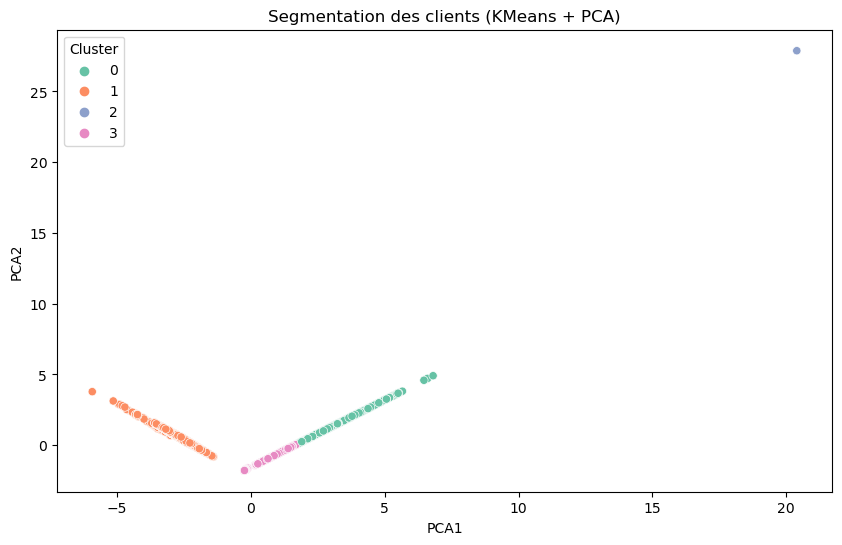

         Montant_Reservations  Note_Moyenne  Nbr_Reservations  Montant_Achats  \
Cluster                                                                         
0                    0.000000      0.000000          0.000000    37516.854219   
1                 3915.303011      2.991646          1.018745        0.000000   
2                    0.000000      0.000000          0.000000        0.000000   
3                    0.000000      0.000000          0.000000    14458.304847   

         Total_Quantité    Nbr_Achats       PCA1       PCA2  
Cluster                                                      
0            756.404360    377.900141   2.574210   0.888163  
1              0.000000      0.000000  -2.526219   0.419495  
2              0.000000  12128.000000  20.390045  27.873999  
3            291.000993    146.550331   0.833915  -0.768305  


In [4]:
# ⚠️ Conversion du champ Total_Prix en float si besoin (ex: 1.451,96 → 1451.96)
# 📌 Conversion conditionnelle si le type est object (chaîne de caractères)
if df_reservations['Total_Prix'].dtype == 'object':
    df_reservations['Total_Prix'] = df_reservations['Total_Prix'].str.replace(',', '.').str.replace(' ', '').astype(float)

if df_achats['Prix_Total'].dtype == 'object':
    df_achats['Prix_Total'] = df_achats['Prix_Total'].str.replace(',', '.').str.replace(' ', '').astype(float)

reserv_summary = df_reservations.groupby('ClientID_FK').agg({
    'Total_Prix': 'sum',
    'Note_Client': 'mean',
    'Reservation_PK': 'count'
}).rename(columns={
    'Total_Prix': 'Montant_Reservations',
    'Note_Client': 'Note_Moyenne',
    'Reservation_PK': 'Nbr_Reservations'
})

achat_summary = df_achats.groupby('Client_FK').agg({
    'Prix_Total': 'sum',
    'Quantité_Achetée': 'sum',
    'AchatID_PK': 'count'
}).rename(columns={
    'Prix_Total': 'Montant_Achats',
    'Quantité_Achetée': 'Total_Quantité',
    'AchatID_PK': 'Nbr_Achats'
})
# 📌 5. Fusion des données sur les clients
client_behavior = reserv_summary.merge(achat_summary, left_index=True, right_index=True, how='outer')
client_behavior = client_behavior.fillna(0)

# 📌 6. Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(client_behavior)

# 📌 7. Application de KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
client_behavior['Cluster'] = kmeans.fit_predict(X_scaled)

# 📌 8. Visualisation avec PCA (réduction dimensionnelle)
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

client_behavior['PCA1'] = components[:, 0]
client_behavior['PCA2'] = components[:, 1]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=client_behavior, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('Segmentation des clients (KMeans + PCA)')
plt.show()

# 📌 9. Interprétation
print(client_behavior.groupby('Cluster').mean())

In [ ]:
# Hypothèse :

#Cluster 0 & 3 : Clients acheteurs, mais 0 réservations.

#Cluster 1 : Clients réservateurs, mais 0 achats.

#Cluster 2 : Client avec une activité anormale (peut-être une erreur ?).
#PCA (Principal Component Analysis) est une technique de réduction de dimensionnalité.

In [6]:
#Vérification et exclusion des valeurs extrêmes (Cluster 2)
# Détection des valeurs extrêmes via IQR (Interquartile Range)
Q1 = client_behavior.quantile(0.25)
Q3 = client_behavior.quantile(0.75)
IQR = Q3 - Q1

# Définition des seuils
seuil_bas = Q1 - 1.5 * IQR
seuil_haut = Q3 + 1.5 * IQR
# Filtrer les valeurs extrêmes (Cluster 2)
client_behavior_filtered = client_behavior[
    (client_behavior['PCA1'] > seuil_bas['PCA1']) & (client_behavior['PCA1'] < seuil_haut['PCA1']) &
    (client_behavior['PCA2'] > seuil_bas['PCA2']) & (client_behavior['PCA2'] < seuil_haut['PCA2'])
]

# Vérifier les statistiques après filtrage
client_behavior_filtered.groupby('Cluster').mean()

,Montant_Reservations,Note_Moyenne,Nbr_Reservations,Montant_Achats,Total_Quantité,Nbr_Achats,PCA1,PCA2
Cluster,,,,,,,,
0,0.000000,0.000000,0.000000,36368.414020,733.239621,366.369264,2.487541,0.805659
1,3889.960695,2.991418,1.015529,0.000000,0.000000,0.000000,-2.519092,0.412160
3,0.000000,0.000000,0.000000,14458.304847,291.000993,146.550331,0.833915,-0.768305


In [ ]:
#Le Cluster 2 était composé de valeurs extrêmes ou aberrantes (probablement des erreurs ou des cas isolés)

In [8]:
# Analyse des segments (habitudes, montant moyen, fréquence)
# Calcul des statistiques par cluster
cluster_analysis = client_behavior.groupby('Cluster').agg({
    'Montant_Reservations': ['mean', 'median', 'max', 'min'],
    'Nbr_Reservations': ['mean', 'median', 'max', 'min'],
    'Montant_Achats': ['mean', 'median', 'max', 'min'],
    'Total_Quantité': ['mean', 'median', 'max', 'min'],
    'Nbr_Achats': ['mean', 'median', 'max', 'min']
})

print(cluster_analysis)


        Montant_Reservations                           Nbr_Reservations  \
                        mean  median       max     min             mean   
Cluster                                                                   
0                   0.000000     0.0      0.00    0.00         0.000000   
1                3915.303011  3890.2  13784.69  105.35         1.018745   
2                   0.000000     0.0      0.00    0.00         0.000000   
3                   0.000000     0.0      0.00    0.00         0.000000   

                         Montant_Achats                                \
        median  max  min           mean     median       max      min   
Cluster                                                                 
0          0.0  0.0  0.0   37516.854219  35035.225  93718.65  25270.3   
1          1.0  3.0  1.0       0.000000      0.000      0.00      0.0   
2          0.0  0.0  0.0       0.000000      0.000      0.00      0.0   
3          0.0  0.0  0.0   14458.304

In [9]:
client_behavior_filtered.to_csv("client_segmentation.csv", index=True)